# Safe Highway Overtaking with iLQR

## 1. Requirement

The ego vehicle should drive on a multi-lane highway, maintain a desired cruising speed, and generate smooth lane-changing trajectories when overtaking slower traffic.

The vehicle uses continuous control inputs:

$$
u_t =
\begin{bmatrix}
a_t \\
\delta_t
\end{bmatrix},
$$

where:

- $a_t$ is longitudinal acceleration,
- $\delta_t$ is steering angle.

The finite-horizon control problem is:

$$
\min_U
\left[
\sum_{k=0}^{N-1}
\ell(x_k,u_k)
+
\phi(x_N)
\right]
$$

subject to:

$$
x_{k+1}=f(x_k,u_k).
$$

Instead of solving this problem with a generic nonlinear optimizer, this notebook uses **iterative Linear Quadratic Regulator (iLQR)**.

## 2. Imports and Environment Setup

In [18]:
import gymnasium as gym
import highway_env

import numpy as np
import matplotlib.pyplot as plt

In [133]:
config = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 12,
        "features": [
            "presence",
            "x",
            "y",
            "vx",
            "vy"
        ],
        "absolute": False,
        "normalize": False,
        "see_behind": True
    },

    "action": {
        "type": "ContinuousAction"
    },

    "lanes_count": 4,
    "vehicles_count": 50,
    "vehicles_density": 2.0,

    "simulation_frequency": 15,
    "policy_frequency": 10,

    "duration": 40
}

env = gym.make(
    "highway-v0",
    render_mode="rgb_array",
    config=config
)

obs, info = env.reset(seed=42)

In [97]:
def inspect_running_traffic(env):

    ego = env.unwrapped.vehicle
    ego_x = ego.position[0]

    print(
        f"EGO | lane={ego.lane_index[2]} | "
        f"x={ego.position[0]:.1f} | "
        f"y={ego.position[1]:.1f} | "
        f"v={ego.speed:.1f}"
    )

    for lane_id in range(config["lanes_count"]):

        front = None
        rear = None

        for vehicle in env.unwrapped.road.vehicles:

            if vehicle is ego:
                continue

            if vehicle.lane_index[2] != lane_id:
                continue

            dx = vehicle.position[0] - ego_x

            if dx > 0:
                if front is None or dx < front[0]:
                    front = (dx, vehicle.speed)

            else:
                if rear is None or dx > rear[0]:
                    rear = (dx, vehicle.speed)

        print(
            f"lane {lane_id} | "
            f"front={front} | "
            f"rear={rear}"
        )

In [126]:
def show_env(env, figsize=(12, 4)):
    frame = env.render()

    plt.figure(figsize=figsize)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

## 3. State and Control

The ego state is:

$$
x=
\begin{bmatrix}
p_x \\
p_y \\
\psi \\
v
\end{bmatrix}
$$

and the control is:

$$
u=
\begin{bmatrix}
a \\
\delta
\end{bmatrix}.
$$

In [20]:
DT = 0.1
WHEELBASE = 2.5

A_MIN = -5.0
A_MAX = 3.0

DELTA_MIN = -0.35
DELTA_MAX = 0.35

V_REF = 25.0
LANE_WIDTH = 4.0

N = 30

## 4. Dynamics

In [21]:
def dynamics(x, u):

    px, py, psi, v = x
    a, delta = u

    px_next = (
        px
        + DT * v * np.cos(psi)
    )

    py_next = (
        py
        + DT * v * np.sin(psi)
    )

    psi_next = (
        psi
        + DT * v / WHEELBASE * np.tan(delta)
    )

    v_next = (
        v
        + DT * a
    )

    return np.array([
        px_next,
        py_next,
        psi_next,
        v_next
    ])

In [22]:
def rollout(x0, U):

    X = np.zeros((N + 1, 4))

    X[0] = x0

    for k in range(N):
        X[k + 1] = dynamics(
            X[k],
            U[k]
        )

    return X

## 5. Running and Terminal Cost

In [23]:
W_Y = 2.0
W_PSI = 3.0
W_V = 1.0

W_A = 0.1
W_DELTA = 0.5

W_TERMINAL_Y = 20.0
W_TERMINAL_PSI = 20.0
W_TERMINAL_V = 5.0

In [24]:
def running_cost(x, u, y_ref):

    px, py, psi, v = x
    a, delta = u

    return (
        W_Y * (py - y_ref)**2
        + W_PSI * psi**2
        + W_V * (v - V_REF)**2
        + W_A * a**2
        + W_DELTA * delta**2
    )

In [25]:
def terminal_cost(x, y_ref):

    px, py, psi, v = x

    return (
        W_TERMINAL_Y * (py - y_ref)**2
        + W_TERMINAL_PSI * psi**2
        + W_TERMINAL_V * (v - V_REF)**2
    )

## 6. Linearization of the Dynamics

At every point along the nominal trajectory, the nonlinear dynamics are
linearized:

$$
\delta x_{k+1}
\approx
A_k\delta x_k
+
B_k\delta u_k
$$

with:

$$
A_k=
\left.
\frac{\partial f}{\partial x}
\right|_{\bar x_k,\bar u_k}
$$

and:

$$
B_k=
\left.
\frac{\partial f}{\partial u}
\right|_{\bar x_k,\bar u_k}.
$$

These matrices are recomputed along the current nominal trajectory during
each iLQR iteration.

In [26]:
def dynamics_jacobians(x, u):

    px, py, psi, v = x
    a, delta = u

    A = np.eye(4)

    # derivatives of px_next
    A[0, 2] = -DT * v * np.sin(psi)
    A[0, 3] =  DT * np.cos(psi)

    # derivatives of py_next
    A[1, 2] = DT * v * np.cos(psi)
    A[1, 3] = DT * np.sin(psi)

    # derivatives of psi_next
    A[2, 3] = (
        DT / WHEELBASE
        * np.tan(delta)
    )

    B = np.zeros((4, 2))

    # v_next derivative wrt acceleration
    B[3, 0] = DT

    # psi_next derivative wrt steering
    B[2, 1] = (
        DT
        * v
        / WHEELBASE
        / np.cos(delta)**2
    )

    return A, B

## 7. Cost derivatives

## 8. Terminal Value Function

At the end of the horizon there is no future running cost.

Therefore:

$$
V_N(x_N)=\phi(x_N).
$$

The iLQR backward pass is initialized using the gradient and Hessian of the
terminal cost:

$$
V_x(N)=\phi_x(x_N)
$$

$$
V_{xx}(N)=\phi_{xx}(x_N).
$$

In [28]:
def terminal_cost_derivatives(x, y_ref):

    px, py, psi, v = x

    Vx = np.array([
        0.0,
        2.0 * W_TERMINAL_Y * (py - y_ref),
        2.0 * W_TERMINAL_PSI * psi,
        2.0 * W_TERMINAL_V * (v - V_REF)
    ])

    Vxx = np.diag([
        0.0,
        2.0 * W_TERMINAL_Y,
        2.0 * W_TERMINAL_PSI,
        2.0 * W_TERMINAL_V
    ])

    return Vx, Vxx

## 9. iLQR Backward Pass

The backward pass starts from the terminal value function:

$$
V_x(N)=\phi_x(x_N)
$$

$$
V_{xx}(N)=\phi_{xx}(x_N).
$$

At each timestep $k$, the local state-action value approximation is formed using:

$$
Q_x=
\ell_x
+
A_k^\top V_x
$$

$$
Q_u=
\ell_u
+
B_k^\top V_x
$$

$$
Q_{xx}=
\ell_{xx}
+
A_k^\top V_{xx}A_k
$$

$$
Q_{uu}=
\ell_{uu}
+
B_k^\top V_{xx}B_k
$$

$$
Q_{ux}=
\ell_{ux}
+
B_k^\top V_{xx}A_k.
$$

In [27]:
def running_cost_derivatives(x, u, y_ref):

    px, py, psi, v = x
    a, delta = u

    # Gradient wrt state
    lx = np.array([
        0.0,
        2.0 * W_Y * (py - y_ref),
        2.0 * W_PSI * psi,
        2.0 * W_V * (v - V_REF)
    ])

    # Gradient wrt control
    lu = np.array([
        2.0 * W_A * a,
        2.0 * W_DELTA * delta
    ])

    # Hessian wrt state
    lxx = np.diag([
        0.0,
        2.0 * W_Y,
        2.0 * W_PSI,
        2.0 * W_V
    ])

    # Hessian wrt control
    luu = np.diag([
        2.0 * W_A,
        2.0 * W_DELTA
    ])

    # Mixed state-control derivative
    lux = np.zeros((2, 4))

    return lx, lu, lxx, luu, lux

In [63]:
def backward_pass(X, U, y_ref, regularization=1e-6):

    # Feedback gains
    K_list = np.zeros((N, 2, 4))

    # Feedforward gains
    k_list = np.zeros((N, 2))

    # Initialize value function from terminal cost
    Vx, Vxx = terminal_cost_derivatives(
        X[-1],
        y_ref
    )

    for k in reversed(range(N)):

        x = X[k]
        u = U[k]

        # Dynamics linearization
        A, B = dynamics_jacobians(
            x,
            u
        )

        # Running-cost derivatives
        lx, lu, lxx, luu, lux = (
            running_cost_derivatives(
                x,
                u,
                y_ref
            )
        )

        # -------------------------
        # Q-function derivatives
        # -------------------------

        Qx = (
            lx
            + A.T @ Vx
        )

        Qu = (
            lu
            + B.T @ Vx
        )

        Qxx = (
            lxx
            + A.T @ Vxx @ A
        )

        Quu = (
            luu
            + B.T @ Vxx @ B
        )

        Qux = (
            lux
            + B.T @ Vxx @ A
        )

        # Numerical regularization
        Quu_reg = (
            Quu
            + regularization * np.eye(2)
        )

        # -------------------------
        # Optimal local corrections
        # -------------------------

        k_ff = -np.linalg.solve(
            Quu_reg,
            Qu
        )

        K_fb = -np.linalg.solve(
            Quu_reg,
            Qux
        )

        k_list[k] = k_ff
        K_list[k] = K_fb

        # -------------------------
        # Update value function
        # -------------------------

        Vx = (
            Qx
            + K_fb.T @ Quu @ k_ff
            + K_fb.T @ Qu
            + Qux.T @ k_ff
        )

        Vxx = (
            Qxx
            + K_fb.T @ Quu @ K_fb
            + K_fb.T @ Qux
            + Qux.T @ K_fb
        )

        # Keep Hessian numerically symmetric
        Vxx = 0.5 * (
            Vxx + Vxx.T
        )

    return k_list, K_list

## 10. Forward Pass

The backward pass computes local feedforward and feedback corrections:

$$
k_k,\qquad K_k.
$$

A new control sequence is generated using:

$$
u_k^{new}=
\bar u_k
+
\alpha k_k
+
K_k
\left(
x_k^{new}-\bar x_k
\right).
$$

The updated controls are then propagated through the original nonlinear
dynamics:

$$
x_{k+1}^{new}=
f(x_k^{new},u_k^{new}).
$$

Thus, the backward pass determines how the controls should change, while
the forward pass generates the corresponding new nonlinear trajectory.

In [30]:
def total_cost(X, U, y_ref):

    cost = 0.0

    for k in range(N):
        cost += running_cost(
            X[k],
            U[k],
            y_ref
        )

    cost += terminal_cost(
        X[-1],
        y_ref
    )

    return cost

In [31]:
def forward_pass(
    X_nom,
    U_nom,
    k_list,
    K_list,
    y_ref,
    alpha=1.0
):

    X_new = np.zeros_like(X_nom)
    U_new = np.zeros_like(U_nom)

    X_new[0] = X_nom[0]

    for k in range(N):

        dx = (
            X_new[k]
            - X_nom[k]
        )

        du = (
            alpha * k_list[k]
            + K_list[k] @ dx
        )

        U_new[k] = (
            U_nom[k]
            + du
        )

        # Control limits
        U_new[k, 0] = np.clip(
            U_new[k, 0],
            A_MIN,
            A_MAX
        )

        U_new[k, 1] = np.clip(
            U_new[k, 1],
            DELTA_MIN,
            DELTA_MAX
        )

        X_new[k + 1] = dynamics(
            X_new[k],
            U_new[k]
        )

    cost = total_cost(
        X_new,
        U_new,
        y_ref
    )

    return X_new, U_new, cost

## 11. Line Search

Because the backward pass is based on a local approximation of the nonlinear
problem, applying the full feedforward correction may not always improve the
trajectory.

Several step sizes are therefore tested:

$$
\alpha
\in
\{1,\;0.5,\;0.25,\;0.1,\ldots\}.
$$

The trajectory with the lowest cost is accepted.

In [32]:
ALPHAS = [
    1.0,
    0.5,
    0.25,
    0.1,
    0.05
]

## 12. Complete iLQR Solver

In [33]:
def ilqr(
    x0,
    y_ref,
    U_initial=None,
    max_iterations=50,
    tolerance=1e-3
):

    if U_initial is None:
        U = np.zeros((N, 2))
    else:
        U = U_initial.copy()

    # Initial nominal trajectory
    X = rollout(
        x0,
        U
    )

    current_cost = total_cost(
        X,
        U,
        y_ref
    )

    cost_history = [
        current_cost
    ]

    for iteration in range(max_iterations):

        # -----------------------------
        # Backward pass
        # -----------------------------

        k_list, K_list = backward_pass(
            X,
            U,
            y_ref
        )

        best_cost = current_cost
        best_X = None
        best_U = None

        # -----------------------------
        # Forward pass + line search
        # -----------------------------

        for alpha in ALPHAS:

            X_candidate, U_candidate, candidate_cost = (
                forward_pass(
                    X,
                    U,
                    k_list,
                    K_list,
                    y_ref,
                    alpha
                )
            )

            if candidate_cost < best_cost:

                best_cost = candidate_cost
                best_X = X_candidate
                best_U = U_candidate

        # No improving trajectory found
        if best_X is None:
            break

        improvement = (
            current_cost
            - best_cost
        )

        X = best_X
        U = best_U
        current_cost = best_cost

        cost_history.append(
            current_cost
        )

        if improvement < tolerance:
            break

    return X, U, cost_history

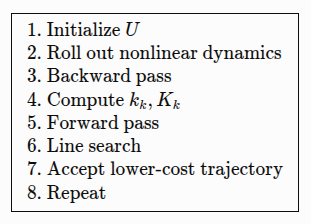

## 13. First Lane-Change Test

In [34]:
x0_test = np.array([
    0.0,
    0.0,
    0.0,
    25.0
])

target_lane = 1
y_ref = target_lane * LANE_WIDTH

X_opt, U_opt, cost_history = ilqr(
    x0_test,
    y_ref
)

In [35]:
print(
    "Initial cost:",
    cost_history[0]
)

print(
    "Final cost:",
    cost_history[-1]
)

print(
    "Iterations:",
    len(cost_history) - 1
)

print(
    "Terminal state:",
    X_opt[-1]
)

Initial cost: 1280.0
Final cost: 90.56187276562925
Iterations: 2
Terminal state: [7.39112094e+01 4.00000000e+00 3.65213596e-18 2.50000022e+01]


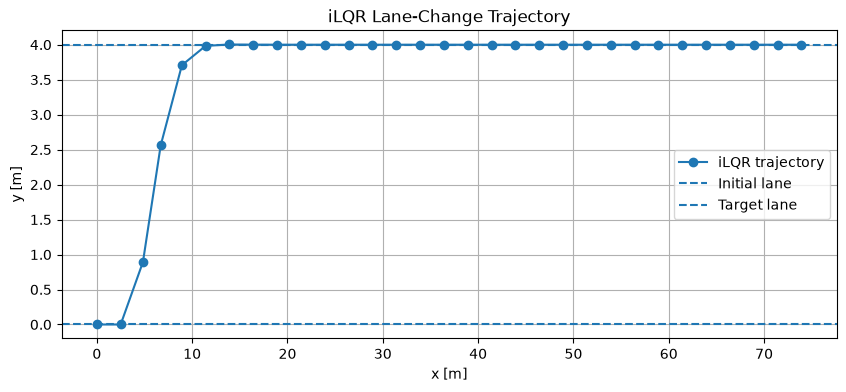

In [36]:
plt.figure(figsize=(10, 4))

plt.plot(
    X_opt[:, 0],
    X_opt[:, 1],
    marker="o",
    label="iLQR trajectory"
)

plt.axhline(
    0.0,
    linestyle="--",
    label="Initial lane"
)

plt.axhline(
    y_ref,
    linestyle="--",
    label="Target lane"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("iLQR Lane-Change Trajectory")
plt.grid(True)
plt.legend()

plt.show()

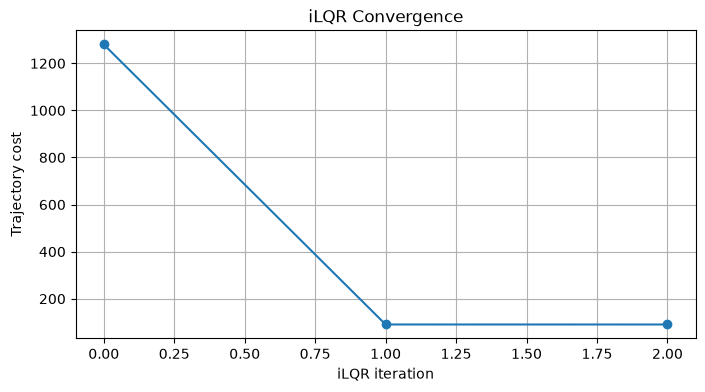

In [37]:
plt.figure(figsize=(8, 4))

plt.plot(
    cost_history,
    marker="o"
)

plt.xlabel("iLQR iteration")
plt.ylabel("Trajectory cost")
plt.title("iLQR Convergence")
plt.grid(True)

plt.show()

## 14. Traffic-Aware iLQR

The basic iLQR solver optimizes a smooth finite-horizon cost.

Unlike the previous SLSQP-based MPC formulation, hard inequality constraints
are not directly handled by the standard iLQR backward pass.

Therefore, surrounding vehicles are initially represented using a smooth
collision-avoidance penalty.

For every predicted ego state and traffic vehicle, we compute the relative
position:

$$
\Delta x = p_x - p_x^i
$$

$$
\Delta y = p_y - p_y^i.
$$

A normalized elliptical distance is defined as:

$$
d_i^2=
\left(
\frac{\Delta x}{d_x}
\right)^2
+
\left(
\frac{\Delta y}{d_y}
\right)^2.
$$

The collision penalty should become large when the ego approaches the
vehicle safety region.

In [38]:
def get_traffic_state(env):

    ego = env.unwrapped.vehicle

    traffic = []

    for vehicle in env.unwrapped.road.vehicles:

        if vehicle is ego:
            continue

        traffic.append({
            "x": float(vehicle.position[0]),
            "y": float(vehicle.position[1]),
            "vx": float(
                vehicle.speed * np.cos(vehicle.heading)
            )
        })

    return traffic

In [39]:
W_OBSTACLE = 200.0

SAFE_LONGITUDINAL = 10.0
SAFE_LATERAL = 2.0

In [40]:
def obstacle_cost(x, traffic, k):

    px, py, psi, v = x

    t = k * DT

    cost = 0.0

    for vehicle in traffic:

        traffic_x = (
            vehicle["x"]
            + vehicle["vx"] * t
        )

        traffic_y = vehicle["y"]

        dx = px - traffic_x
        dy = py - traffic_y

        d2 = (
            (dx / SAFE_LONGITUDINAL)**2
            +
            (dy / SAFE_LATERAL)**2
        )

        cost += (
            W_OBSTACLE
            * np.exp(-d2)
        )

    return cost

In [41]:
def running_cost(
    x,
    u,
    y_ref,
    traffic=None,
    k=0
):

    px, py, psi, v = x
    a, delta = u

    cost = (
        W_Y * (py - y_ref)**2
        + W_PSI * psi**2
        + W_V * (v - V_REF)**2
        + W_A * a**2
        + W_DELTA * delta**2
    )

    if traffic is not None:
        cost += obstacle_cost(
            x,
            traffic,
            k
        )

    return cost

In [42]:
def numerical_gradient(
    fun,
    x,
    eps=1e-5
):

    grad = np.zeros_like(x)

    for i in range(len(x)):

        xp = x.copy()
        xm = x.copy()

        xp[i] += eps
        xm[i] -= eps

        grad[i] = (
            fun(xp) - fun(xm)
        ) / (2 * eps)

    return grad

## 15. Numerical Cost Derivatives

The traffic-aware running cost contains a nonlinear obstacle term.

Instead of manually deriving gradients and Hessians, we approximate them using
central finite differences.

For a scalar function $f(x)$:

Gradient:

$$
\frac{\partial f}{\partial x_i}
\approx
\frac{
f(x+\epsilon e_i)-
f(x-\epsilon e_i)
}
{2\epsilon}
$$

The Hessian is obtained by differentiating the gradient numerically.

In [55]:
def numerical_gradient(fun, z, eps=1e-5):

    grad = np.zeros_like(z)

    for i in range(len(z)):

        zp = z.copy()
        zm = z.copy()

        zp[i] += eps
        zm[i] -= eps

        grad[i] = (
            fun(zp) - fun(zm)
        ) / (2 * eps)

    return grad

In [56]:
def numerical_hessian(fun, z, eps=1e-4):

    n = len(z)

    H = np.zeros((n, n))

    for i in range(n):

        for j in range(n):

            z_pp = z.copy()
            z_pm = z.copy()
            z_mp = z.copy()
            z_mm = z.copy()

            z_pp[i] += eps
            z_pp[j] += eps

            z_pm[i] += eps
            z_pm[j] -= eps

            z_mp[i] -= eps
            z_mp[j] += eps

            z_mm[i] -= eps
            z_mm[j] -= eps

            H[i, j] = (
                fun(z_pp)
                - fun(z_pm)
                - fun(z_mp)
                + fun(z_mm)
            ) / (4 * eps**2)

    return H

## 16. Traffic-aware cost derivatives

In [57]:
def running_cost_derivatives_numeric(
    x,
    u,
    y_ref,
    traffic,
    k
):

    # ---------------------------------
    # State derivatives
    # ---------------------------------

    fx = lambda x_var: running_cost(
        x_var,
        u,
        y_ref,
        traffic,
        k
    )

    lx = numerical_gradient(
        fx,
        x
    )

    lxx = numerical_hessian(
        fx,
        x
    )

    # ---------------------------------
    # Control derivatives
    # ---------------------------------

    fu = lambda u_var: running_cost(
        x,
        u_var,
        y_ref,
        traffic,
        k
    )

    lu = numerical_gradient(
        fu,
        u
    )

    luu = numerical_hessian(
        fu,
        u
    )

    # ---------------------------------
    # Mixed derivative
    # ---------------------------------

    lux = np.zeros((2, 4))

    return lx, lu, lxx, luu, lux

## 17. Verify the derivatives

In [58]:
x_test = np.array([
    100.0,
    4.0,
    0.0,
    25.0
])

u_test = np.array([
    0.0,
    0.0
])

In [59]:
traffic_test = [
    {
        "x": 110.0,
        "y": 4.0,
        "vx": 18.0
    }
]

In [60]:
lx, lu, lxx, luu, lux = (
    running_cost_derivatives_numeric(
        x_test,
        u_test,
        y_ref=4.0,
        traffic=traffic_test,
        k=0
    )
)

print("lx =", lx)
print()

print("lu =", lu)
print()

print("lxx =")
print(lxx)
print()

print("luu =")
print(luu)

lx = [14.71517765  0.          0.          0.        ]

lu = [0. 0.]

lxx =
[[  1.47151766   0.           0.           0.        ]
 [  0.         -32.78794338   0.           0.        ]
 [  0.           0.           5.99999979   0.        ]
 [  0.           0.           0.           2.00000017]]

luu =
[[0.20000002 0.        ]
 [0.         1.00000008]]


## 18. Modify the backward pass

In [65]:
def backward_pass(
    X,
    U,
    y_ref,
    traffic,
    regularization=1e-6
):

    K_list = np.zeros((N, 2, 4))
    k_list = np.zeros((N, 2))

    Vx, Vxx = terminal_cost_derivatives(
        X[-1],
        y_ref
    )

    for k in reversed(range(N)):

        x = X[k]
        u = U[k]

        A, B = dynamics_jacobians(
            x,
            u
        )

        lx, lu, lxx, luu, lux = (
            running_cost_derivatives_numeric(
                x,
                u,
                y_ref,
                traffic,
                k
            )
        )

        Qx = lx + A.T @ Vx
        Qu = lu + B.T @ Vx

        Qxx = (
            lxx
            + A.T @ Vxx @ A
        )

        Quu = (
            luu
            + B.T @ Vxx @ B
        )

        Qux = (
            lux
            + B.T @ Vxx @ A
        )

        Quu_reg = (
            Quu
            + regularization * np.eye(2)
        )

        k_ff = -np.linalg.solve(
            Quu_reg,
            Qu
        )

        K_fb = -np.linalg.solve(
            Quu_reg,
            Qux
        )

        k_list[k] = k_ff
        K_list[k] = K_fb

        Vx = (
            Qx
            + K_fb.T @ Quu @ k_ff
            + K_fb.T @ Qu
            + Qux.T @ k_ff
        )

        Vxx = (
            Qxx
            + K_fb.T @ Quu @ K_fb
            + K_fb.T @ Qux
            + Qux.T @ K_fb
        )

        Vxx = 0.5 * (
            Vxx + Vxx.T
        )

    return k_list, K_list

## where are we now?

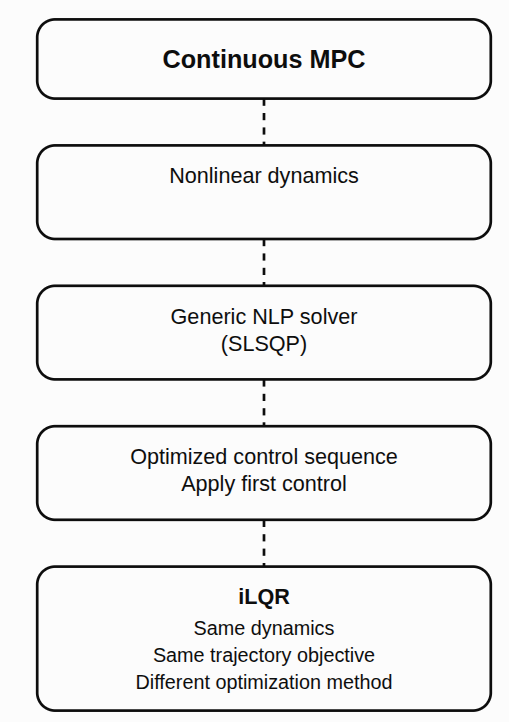

The problem formulation is almost unchanged.

The only real difference is the optimizer.

Instead of solving the nonlinear program directly, iLQR repeatedly performs:

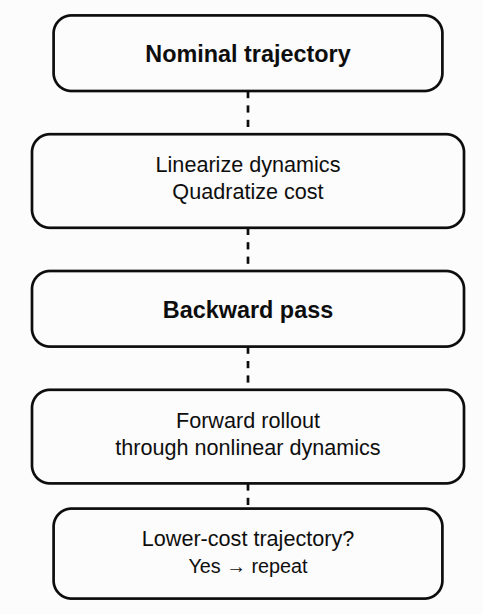

## 19. Make total cost traffic-aware

In [66]:
def total_cost(
    X,
    U,
    y_ref,
    traffic
):

    cost = 0.0

    for k in range(N):

        cost += running_cost(
            X[k],
            U[k],
            y_ref,
            traffic,
            k
        )

    cost += terminal_cost(
        X[-1],
        y_ref
    )

    return cost

In [67]:
def forward_pass(
    X_nom,
    U_nom,
    k_list,
    K_list,
    y_ref,
    traffic,
    alpha=1.0
):

    X_new = np.zeros_like(X_nom)
    U_new = np.zeros_like(U_nom)

    X_new[0] = X_nom[0]

    for k in range(N):

        dx = (
            X_new[k]
            - X_nom[k]
        )

        du = (
            alpha * k_list[k]
            + K_list[k] @ dx
        )

        U_new[k] = (
            U_nom[k] + du
        )

        U_new[k, 0] = np.clip(
            U_new[k, 0],
            A_MIN,
            A_MAX
        )

        U_new[k, 1] = np.clip(
            U_new[k, 1],
            DELTA_MIN,
            DELTA_MAX
        )

        X_new[k + 1] = dynamics(
            X_new[k],
            U_new[k]
        )

    cost = total_cost(
        X_new,
        U_new,
        y_ref,
        traffic
    )

    return X_new, U_new, cost

Then update forward_pass()

In [68]:
def forward_pass(
    X_nom,
    U_nom,
    k_list,
    K_list,
    y_ref,
    traffic,
    alpha=1.0
):

    X_new = np.zeros_like(X_nom)
    U_new = np.zeros_like(U_nom)

    X_new[0] = X_nom[0]

    for k in range(N):

        dx = (
            X_new[k]
            - X_nom[k]
        )

        du = (
            alpha * k_list[k]
            + K_list[k] @ dx
        )

        U_new[k] = (
            U_nom[k] + du
        )

        U_new[k, 0] = np.clip(
            U_new[k, 0],
            A_MIN,
            A_MAX
        )

        U_new[k, 1] = np.clip(
            U_new[k, 1],
            DELTA_MIN,
            DELTA_MAX
        )

        X_new[k + 1] = dynamics(
            X_new[k],
            U_new[k]
        )

    cost = total_cost(
        X_new,
        U_new,
        y_ref,
        traffic
    )

    return X_new, U_new, cost

## 20. Update the iLQR solver

In [69]:
def ilqr(
    x0,
    y_ref,
    traffic,
    U_initial=None,
    max_iterations=50,
    tolerance=1e-3
):

    if U_initial is None:
        U = np.zeros((N, 2))
    else:
        U = U_initial.copy()

    X = rollout(
        x0,
        U
    )

    current_cost = total_cost(
        X,
        U,
        y_ref,
        traffic
    )

    cost_history = [
        current_cost
    ]

    for iteration in range(max_iterations):

        k_list, K_list = backward_pass(
            X,
            U,
            y_ref,
            traffic
        )

        best_cost = current_cost
        best_X = None
        best_U = None

        for alpha in ALPHAS:

            X_candidate, U_candidate, candidate_cost = (
                forward_pass(
                    X,
                    U,
                    k_list,
                    K_list,
                    y_ref,
                    traffic,
                    alpha
                )
            )

            if candidate_cost < best_cost:

                best_cost = candidate_cost
                best_X = X_candidate
                best_U = U_candidate

        if best_X is None:
            break

        improvement = (
            current_cost
            - best_cost
        )

        X = best_X
        U = best_U
        current_cost = best_cost

        cost_history.append(
            current_cost
        )

        if improvement < tolerance:
            break

    return X, U, cost_history

## 21. Deterministic Overtaking Scenario

To test traffic-aware iLQR, we construct a simple highway scenario:

- ego vehicle starts in lane 1,
- ego speed is 25 m/s,
- a slower vehicle is placed ahead in the same lane,
- adjacent lanes remain available.

For each candidate lane, iLQR optimizes a continuous trajectory toward the corresponding lane center.

The optimized costs are then compared:

$$
J_0^*, \quad J_1^*, \quad J_2^*.
$$

The lane with the lowest optimized cost is selected.

In [75]:
def lane_center(lane):
    return lane * LANE_WIDTH

In [76]:
x0_test = np.array([
    100.0,   # px
    4.0,     # py -> lane 1
    0.0,     # heading
    25.0     # speed
])

In [77]:
traffic_test = [
    {
        "x": 135.0,
        "y": 4.0,
        "vx": 18.0
    }
]

In [78]:
candidate_lanes = [0, 1, 2]

In [79]:
solutions = []

for lane in candidate_lanes:

    y_ref = lane_center(lane)

    X_opt, U_opt, cost_history = ilqr(
        x0=x0_test,
        y_ref=y_ref,
        traffic=traffic_test
    )

    solutions.append({
        "lane": lane,
        "y_ref": y_ref,
        "X": X_opt,
        "U": U_opt,
        "cost": cost_history[-1],
        "cost_history": cost_history
    })

In [80]:
for solution in solutions:

    print(
        f"lane={solution['lane']} | "
        f"cost={solution['cost']:.2f} | "
        f"iterations={len(solution['cost_history']) - 1}"
    )

lane=0 | cost=91.83 | iterations=5
lane=1 | cost=73.24 | iterations=3
lane=2 | cost=91.83 | iterations=5


In [81]:
best_solution = min(
    solutions,
    key=lambda s: s["cost"]
)

print(
    "Selected lane:",
    best_solution["lane"]
)

print(
    "Best cost:",
    best_solution["cost"]
)

Selected lane: 1
Best cost: 73.24136145111531


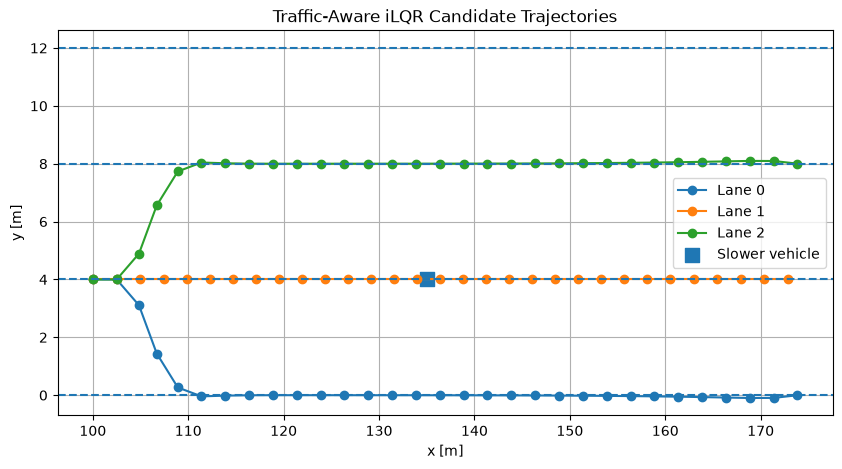

In [82]:
plt.figure(figsize=(10, 5))

for solution in solutions:

    X = solution["X"]

    plt.plot(
        X[:, 0],
        X[:, 1],
        marker="o",
        label=f"Lane {solution['lane']}"
    )

# Lane centers
for lane in range(4):
    plt.axhline(
        lane_center(lane),
        linestyle="--"
    )

plt.scatter(
    traffic_test[0]["x"],
    traffic_test[0]["y"],
    s=100,
    marker="s",
    label="Slower vehicle"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Traffic-Aware iLQR Candidate Trajectories")
plt.grid(True)
plt.legend()

plt.show()

In [83]:
for solution in solutions:
    print(
        f"lane={solution['lane']} | "
        f"cost={solution['cost']:.2f} | "
        f"iterations={len(solution['cost_history']) - 1}"
    )

best_solution = min(
    solutions,
    key=lambda s: s["cost"]
)

print("\nSelected lane:", best_solution["lane"])
print("Best cost:", best_solution["cost"])
print("First control:", best_solution["U"][0])

lane=0 | cost=91.83 | iterations=5
lane=1 | cost=73.24 | iterations=3
lane=2 | cost=91.83 | iterations=5

Selected lane: 1
Best cost: 73.24136145111531
First control: [-2.74194598  0.        ]


In [84]:
def shift_controls(U):
    U_shift = np.zeros_like(U)

    U_shift[:-1] = U[1:]
    U_shift[-1] = U[-1]

    return U_shift

In [85]:
def solve_candidate_lanes(
    x0,
    traffic,
    current_lane,
    U_warm=None
):

    candidate_lanes = [current_lane]

    if current_lane > 0:
        candidate_lanes.append(current_lane - 1)

    if current_lane < 3:
        candidate_lanes.append(current_lane + 1)

    solutions = []

    for lane in candidate_lanes:

        y_ref = lane_center(lane)

        X_opt, U_opt, cost_history = ilqr(
            x0=x0,
            y_ref=y_ref,
            traffic=traffic,
            U_initial=U_warm
        )

        solutions.append({
            "lane": lane,
            "X": X_opt,
            "U": U_opt,
            "cost": cost_history[-1],
            "history": cost_history
        })

    return solutions

In [86]:
def choose_best_ilqr_solution(solutions):

    return min(
        solutions,
        key=lambda s: s["cost"]
    )

In [87]:
def get_ego_state(env):

    ego = env.unwrapped.vehicle

    return np.array([
        float(ego.position[0]),
        float(ego.position[1]),
        float(ego.heading),
        float(ego.speed)
    ])

In [88]:
def normalize_control(a, delta):

    if a >= 0:
        a_norm = a / A_MAX
    else:
        a_norm = -a / A_MIN

    delta_norm = delta / DELTA_MAX

    return np.array([
        np.clip(a_norm, -1.0, 1.0),
        np.clip(delta_norm, -1.0, 1.0)
    ])

In [116]:
obs, info = env.reset(seed=42)

ego = env.unwrapped.vehicle

# Pick one traffic vehicle
slow_vehicle = next(
    v for v in env.unwrapped.road.vehicles
    if v is not ego
)

# --------------------------------
# Put ego in lane 1
# --------------------------------

lane_idx = ("0", "1", 1)

lane = env.unwrapped.road.network.get_lane(
    lane_idx
)

ego.position = lane.position(
    longitudinal=100.0,
    lateral=0.0
)

ego.heading = lane.heading_at(
    100.0
)

ego.speed = 25.0


# --------------------------------
# Put slower vehicle 35 m ahead
# --------------------------------

slow_vehicle.position = lane.position(
    longitudinal=135.0,
    lateral=0.0
)

slow_vehicle.heading = lane.heading_at(
    135.0
)

slow_vehicle.speed = 18.0


# --------------------------------
# Synchronize lane metadata
# --------------------------------

ego.lane_index = (
    env.unwrapped.road.network.get_closest_lane_index(
        ego.position,
        ego.heading
    )
)

slow_vehicle.lane_index = (
    env.unwrapped.road.network.get_closest_lane_index(
        slow_vehicle.position,
        slow_vehicle.heading
    )
)


# --------------------------------
# Synchronize target lanes
# --------------------------------

if hasattr(ego, "target_lane_index"):
    ego.target_lane_index = (
        ego.lane_index
    )

if hasattr(slow_vehicle, "target_lane_index"):
    slow_vehicle.target_lane_index = (
        slow_vehicle.lane_index
    )

In [117]:
print("Ego:")
print("  position:", ego.position)
print("  lane:", ego.lane_index)
print("  speed:", ego.speed)

print("\nSlow vehicle:")
print("  position:", slow_vehicle.position)
print("  lane:", slow_vehicle.lane_index)
print("  speed:", slow_vehicle.speed)

print(
    "\nRelative:",
    slow_vehicle.position - ego.position
)

Ego:
  position: [100.   4.]
  lane: ('0', '1', 1)
  speed: 25.0

Slow vehicle:
  position: [135.   4.]
  lane: ('0', '1', 1)
  speed: 18.0

Relative: [35.  0.]


In [118]:
inspect_running_traffic(env)

EGO | lane=1 | x=100.0 | y=4.0 | v=25.0
lane 0 | front=(np.float64(417.7522192135609), 23.5602092198045) | rear=None
lane 1 | front=(np.float64(35.0), 18.0) | rear=None
lane 2 | front=(np.float64(113.64165550520181), 23.28341910597106) | rear=None
lane 3 | front=(np.float64(129.25445934503466), 22.3511578136867) | rear=None


In [119]:
print(
    slow_vehicle in env.unwrapped.road.vehicles
)

True


In [120]:
U_warm = None

for step in range(30):

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    solutions = solve_candidate_lanes(
        x0,
        traffic,
        current_lane,
        U_warm
    )

    best = choose_best_ilqr_solution(
        solutions
    )

    U_opt = best["U"]

    a_cmd = U_opt[0, 0]
    delta_cmd = U_opt[0, 1]

    env_action = normalize_control(
        a_cmd,
        delta_cmd
    )

    obs, reward, terminated, truncated, info = (
        env.step(env_action)
    )

    # Warm start for next iLQR solve
    U_warm = shift_controls(U_opt)

    print(
        f"step={step:2d} | "
        f"lane={current_lane} | "
        f"target={best['lane']} | "
        f"a={a_cmd:6.2f} | "
        f"delta={np.degrees(delta_cmd):6.2f} deg | "
        f"cost={best['cost']:8.2f} | "
        f"crashed={env.unwrapped.vehicle.crashed}"
    )

    if terminated or truncated:
        break

step= 0 | lane=1 | target=1 | a= -2.74 | delta=  0.00 deg | cost=   73.24 | crashed=False
step= 1 | lane=1 | target=1 | a= -2.31 | delta=  0.00 deg | cost=   75.44 | crashed=False
step= 2 | lane=1 | target=1 | a= -1.96 | delta=  0.00 deg | cost=   77.82 | crashed=False
step= 3 | lane=1 | target=1 | a= -1.67 | delta=  0.00 deg | cost=   80.29 | crashed=False
step= 4 | lane=1 | target=1 | a= -1.43 | delta=  0.00 deg | cost=   82.81 | crashed=False
step= 5 | lane=1 | target=1 | a= -1.24 | delta=  0.00 deg | cost=   85.36 | crashed=False
step= 6 | lane=1 | target=1 | a= -1.08 | delta=  0.00 deg | cost=   87.92 | crashed=False
step= 7 | lane=1 | target=1 | a= -0.95 | delta=  0.00 deg | cost=   90.50 | crashed=False
step= 8 | lane=1 | target=1 | a= -0.85 | delta=  0.00 deg | cost=   93.09 | crashed=False
step= 9 | lane=1 | target=1 | a= -0.76 | delta=  0.00 deg | cost=   95.70 | crashed=False
step=10 | lane=1 | target=0 | a=  2.68 | delta=-20.05 deg | cost=   97.80 | crashed=False
step=11 | 

## 22. Record iLQR Highway-env Episode

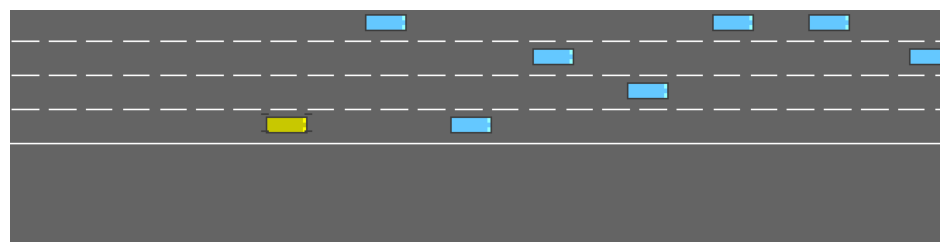

In [134]:
obs, info = env.reset()
show_env(env)

In [135]:
frames = []
U_warm = None

episode_log = []

In [136]:
for step in range(100):

    # --------------------------------
    # Current environment state
    # --------------------------------

    x0 = get_ego_state(env)
    traffic = get_traffic_state(env)

    current_lane = int(
        env.unwrapped.vehicle.lane_index[2]
    )

    # --------------------------------
    # Solve candidate lane trajectories
    # --------------------------------

    solutions = solve_candidate_lanes(
        x0,
        traffic,
        current_lane,
        U_warm
    )

    best = choose_best_ilqr_solution(
        solutions
    )

    U_opt = best["U"]

    # First optimal control
    a_cmd = U_opt[0, 0]
    delta_cmd = U_opt[0, 1]

    env_action = normalize_control(
        a_cmd,
        delta_cmd
    )

    # --------------------------------
    # Apply control
    # --------------------------------

    obs, reward, terminated, truncated, info = (
        env.step(env_action)
    )

    # --------------------------------
    # Record frame
    # --------------------------------

    frame = env.render()

    if frame is not None:
        frames.append(frame)

    # --------------------------------
    # Warm start next iLQR solve
    # --------------------------------

    U_warm = shift_controls(U_opt)

    # --------------------------------
    # Log
    # --------------------------------

    episode_log.append({
        "step": step,
        "lane": current_lane,
        "target_lane": best["lane"],
        "speed": env.unwrapped.vehicle.speed,
        "acceleration": a_cmd,
        "steering": delta_cmd,
        "cost": best["cost"],
        "crashed": env.unwrapped.vehicle.crashed
    })

    print(
        f"step={step:3d} | "
        f"lane={current_lane} | "
        f"target={best['lane']} | "
        f"v={env.unwrapped.vehicle.speed:5.1f} | "
        f"a={a_cmd:6.2f} | "
        f"delta={np.degrees(delta_cmd):6.2f} deg | "
        f"cost={best['cost']:8.2f} | "
        f"crashed={env.unwrapped.vehicle.crashed}"
    )

    if terminated or truncated:
        break

step=  0 | lane=3 | target=3 | v= 24.7 | a= -5.00 | delta=  0.00 deg | cost=  175.52 | crashed=False
step=  1 | lane=3 | target=2 | v= 24.8 | a=  0.79 | delta=-20.05 deg | cost=  101.59 | crashed=False
step=  2 | lane=3 | target=3 | v= 24.6 | a= -1.84 | delta= 13.97 deg | cost=  142.48 | crashed=False
step=  3 | lane=3 | target=2 | v= 24.7 | a=  0.91 | delta=-20.05 deg | cost=   59.04 | crashed=False
step=  4 | lane=3 | target=3 | v= 24.6 | a= -2.25 | delta= 20.05 deg | cost=  189.82 | crashed=False
step=  5 | lane=3 | target=2 | v= 24.7 | a=  0.96 | delta=-20.05 deg | cost=   35.06 | crashed=False
step=  6 | lane=2 | target=1 | v= 24.8 | a=  0.84 | delta=-20.05 deg | cost=  174.57 | crashed=False
step=  7 | lane=2 | target=2 | v= 24.8 | a=  0.34 | delta= 20.05 deg | cost=   27.13 | crashed=False
step=  8 | lane=2 | target=2 | v= 24.8 | a=  0.24 | delta= 20.05 deg | cost=   10.55 | crashed=False
step=  9 | lane=2 | target=2 | v= 24.9 | a=  0.14 | delta=  7.26 deg | cost=    7.06 | cras

In [137]:
print("Recorded frames:", len(frames))

Recorded frames: 100


In [138]:
import imageio.v2 as imageio

imageio.mimsave(
    "safe_overtaking_ilqr.mp4",
    frames,
    fps=config["policy_frequency"]
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [139]:
from IPython.display import Video

Video(
    "safe_overtaking_ilqr.mp4",
    embed=True
)